# Cheap-IG vs NAA

Side-by-side experiments for the portable cheap-IG attack and the reference NAA baseline.


In [4]:
from pathlib import Path
import sys

from IPython.display import display

ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT.parent))

from portable_cheap_naa_attack import (
    AttackConfig,
    plot_attack_comparison,
    plot_importance_map_comparison,
    run_attack,
    run_naa_attack,
)

ROOT


PosixPath('/Users/ashentide/PycharmProjects/PaperImplementations/portable_cheap_naa_attack')

In [5]:
image_dir = ROOT / "dataset"
image_paths = sorted(
    str(path.resolve())
    for path in image_dir.rglob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
)

image_paths[:5], len(image_paths)


(['/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00000293.JPEG',
  '/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00002138.JPEG',
  '/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00003014.JPEG',
  '/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00006697.JPEG',
  '/Users/ashentide/Documents/Datasets/imagenet_val/n01440764/ILSVRC2012_val_00007197.JPEG'],
 50000)

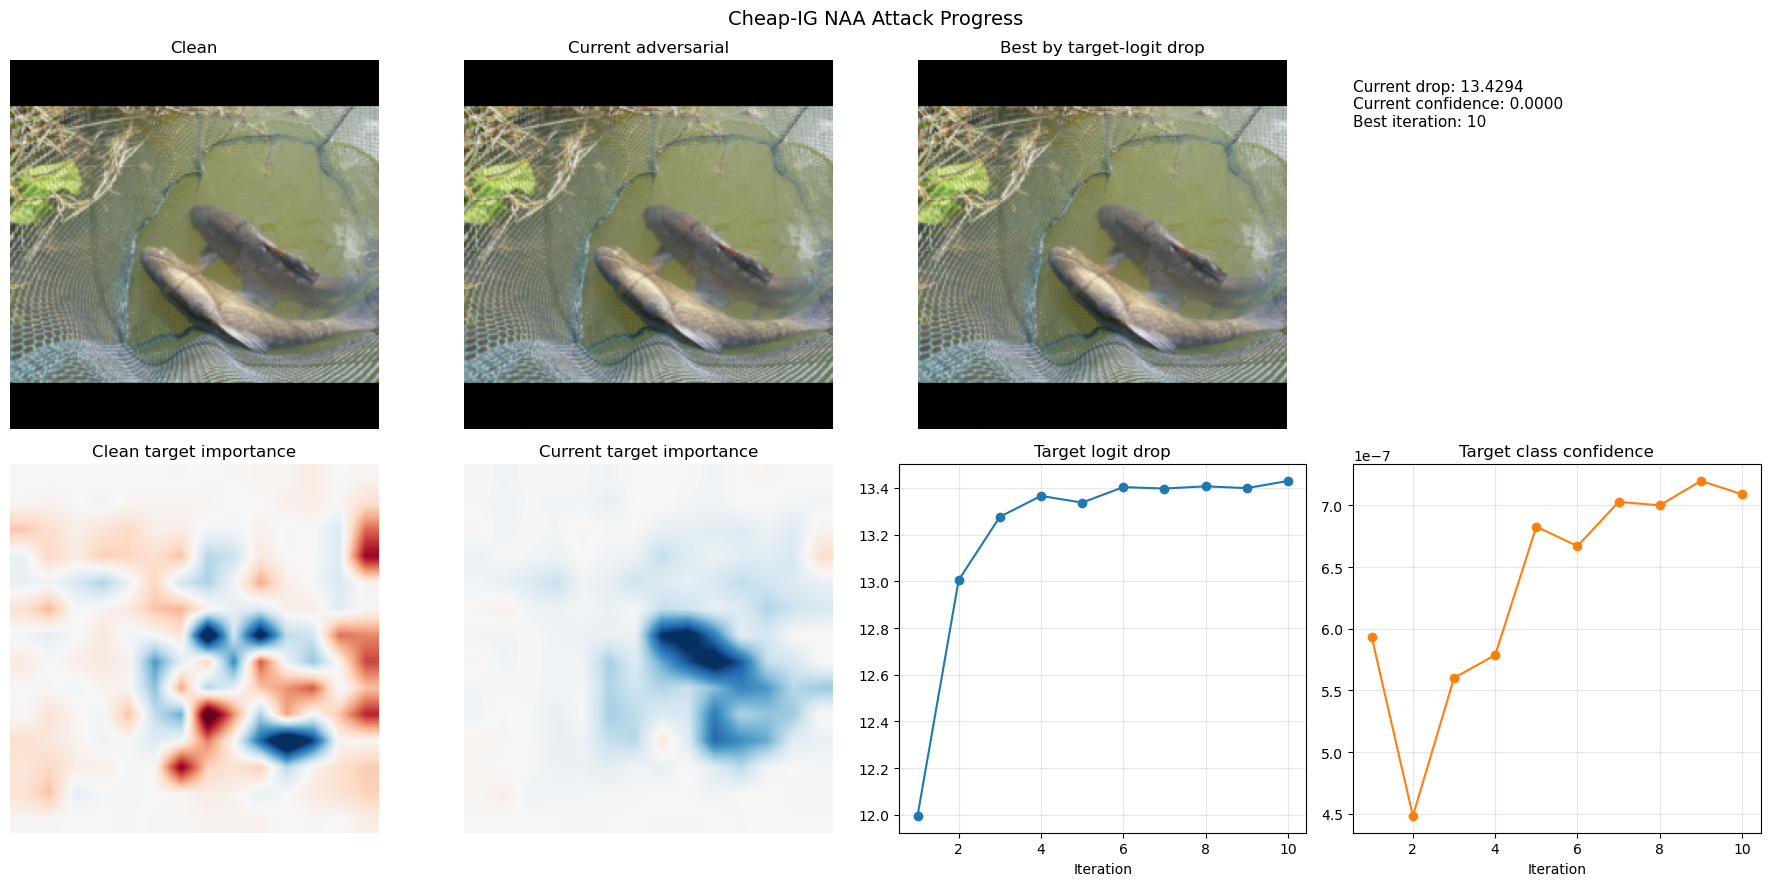

[NAA step 10/10] loss=-5.14017 mean_drop=13.42935


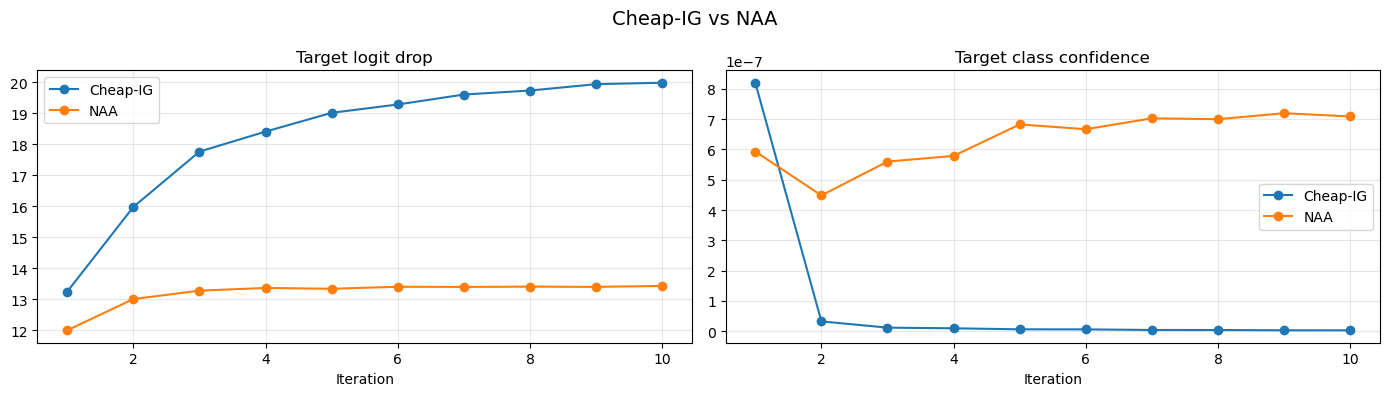

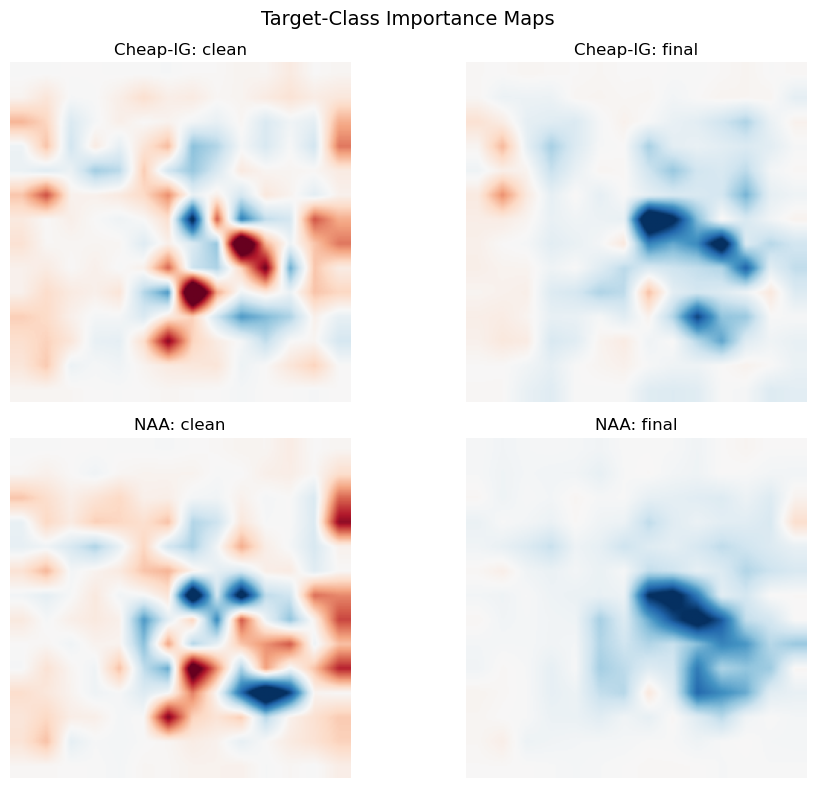

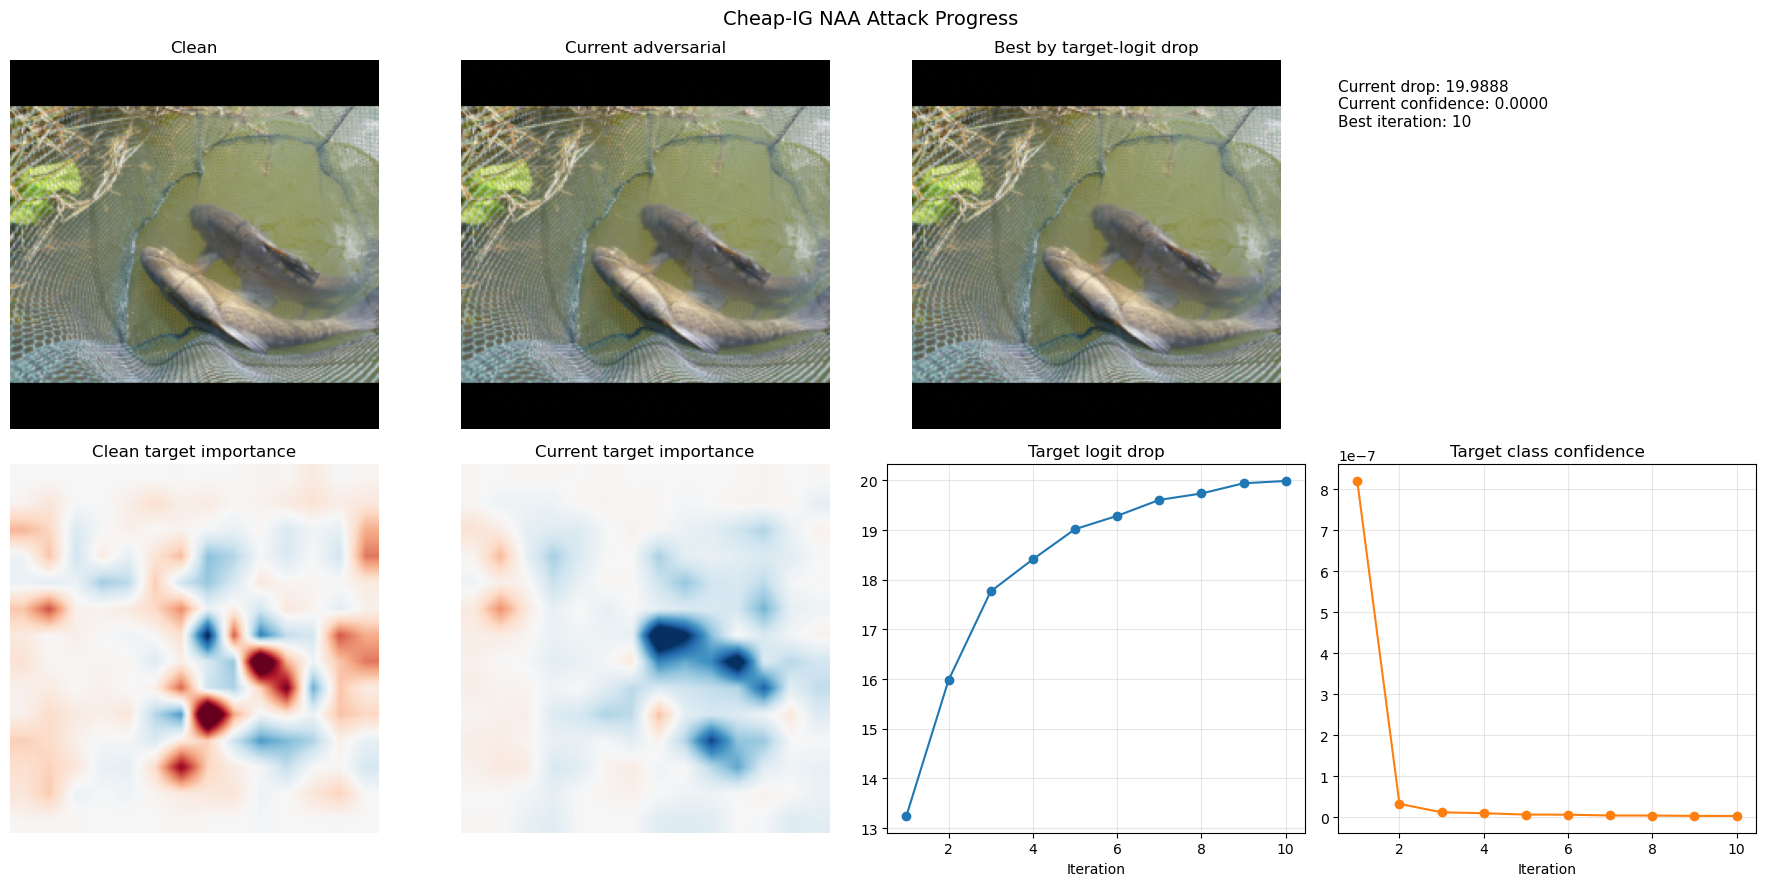

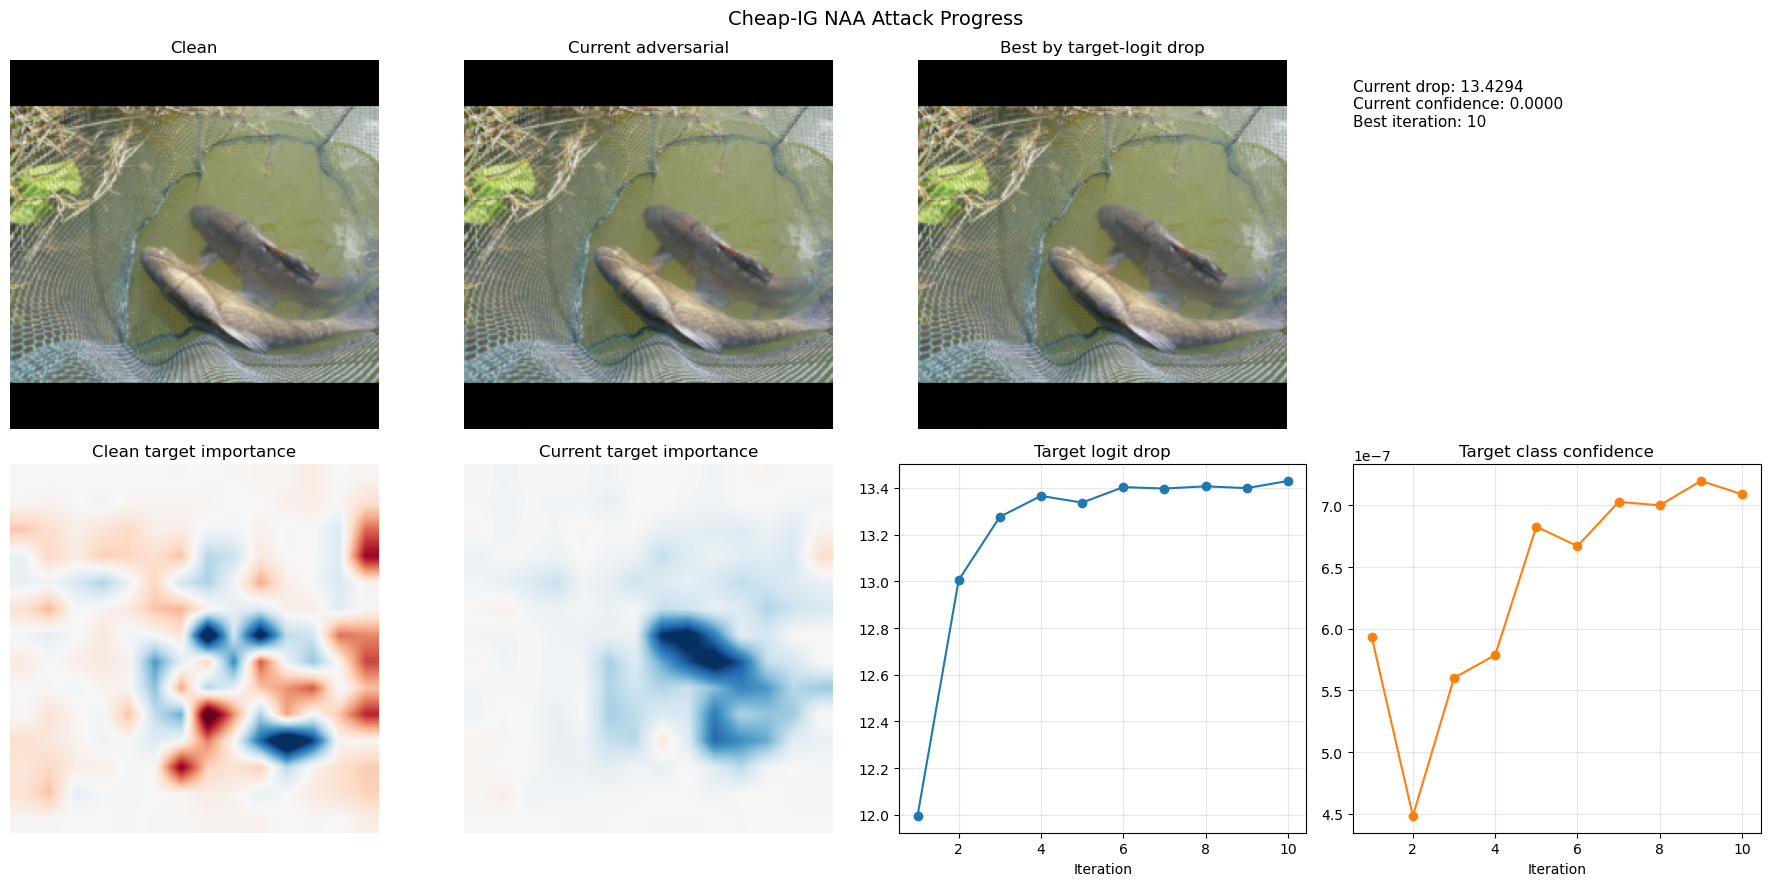

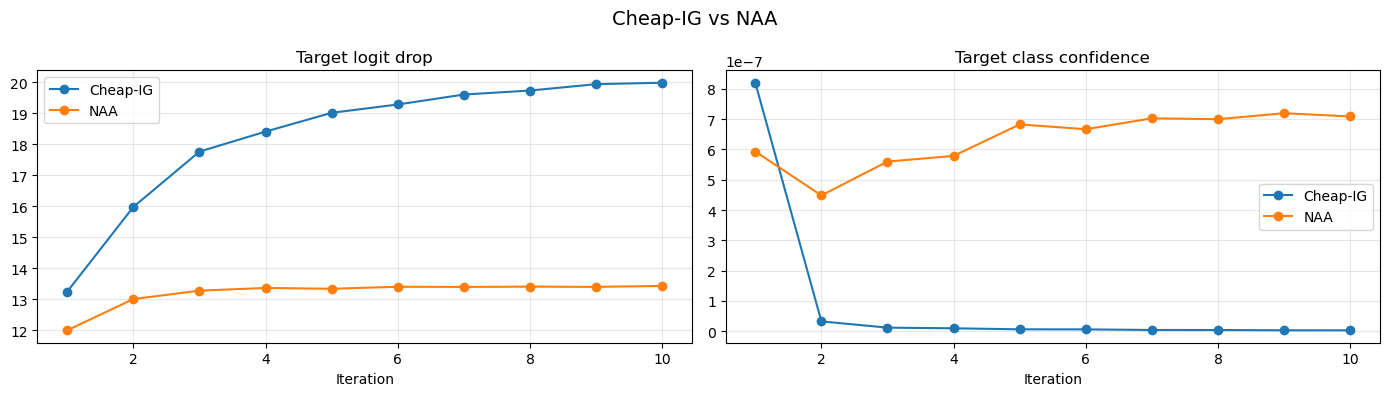

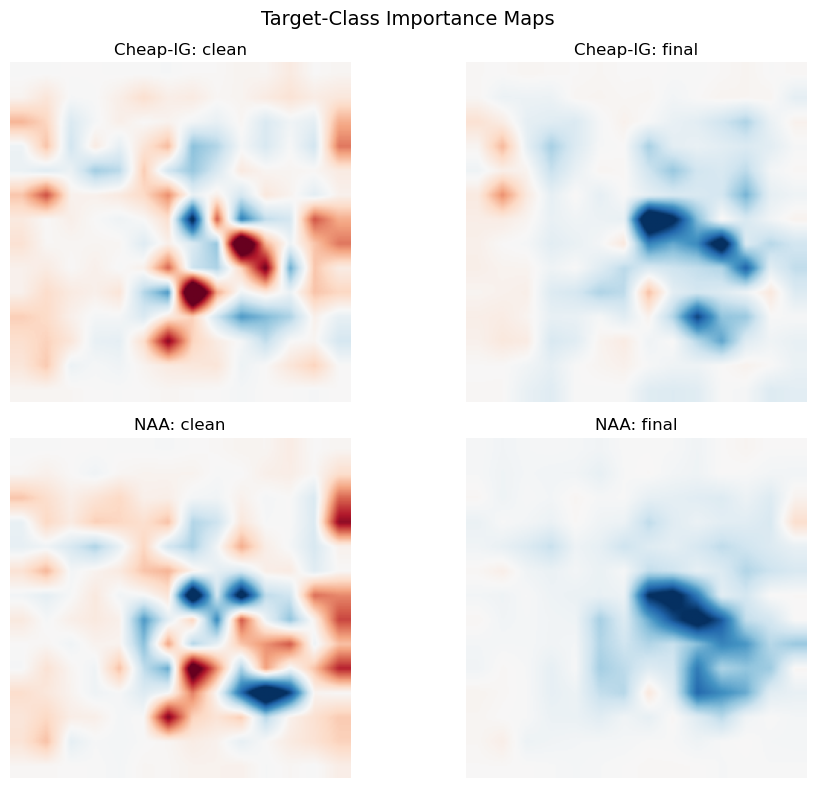

In [9]:
# Single-image experiment.
single_image_paths = image_paths[:1]

cheap_config = AttackConfig(
    output_dir=ROOT / "outputs_compare" / "cheap_ig",
    variant="base",
    live_plots=True,
    verbose=True,
    epsilon=1/255
)
naa_config = AttackConfig(
    output_dir=ROOT / "outputs_compare" / "naa",
    variant="base",
    live_plots=True,
    verbose=True,
    epsilon=1/255
)

cheap_result = run_attack(single_image_paths, cheap_config)
naa_result = run_naa_attack(single_image_paths, naa_config)
fig_curves = plot_attack_comparison(cheap_result, naa_result)
fig_maps = plot_importance_map_comparison(cheap_result, naa_result)
display(fig_curves)
display(fig_maps)

print(f"{cheap_result.method_name}: total={cheap_result.total_runtime_seconds:.2f}s, attribution={cheap_result.attribution_runtime_seconds:.2f}s")
print(f"{naa_result.method_name}: total={naa_result.total_runtime_seconds:.2f}s, attribution={naa_result.attribution_runtime_seconds:.2f}s")


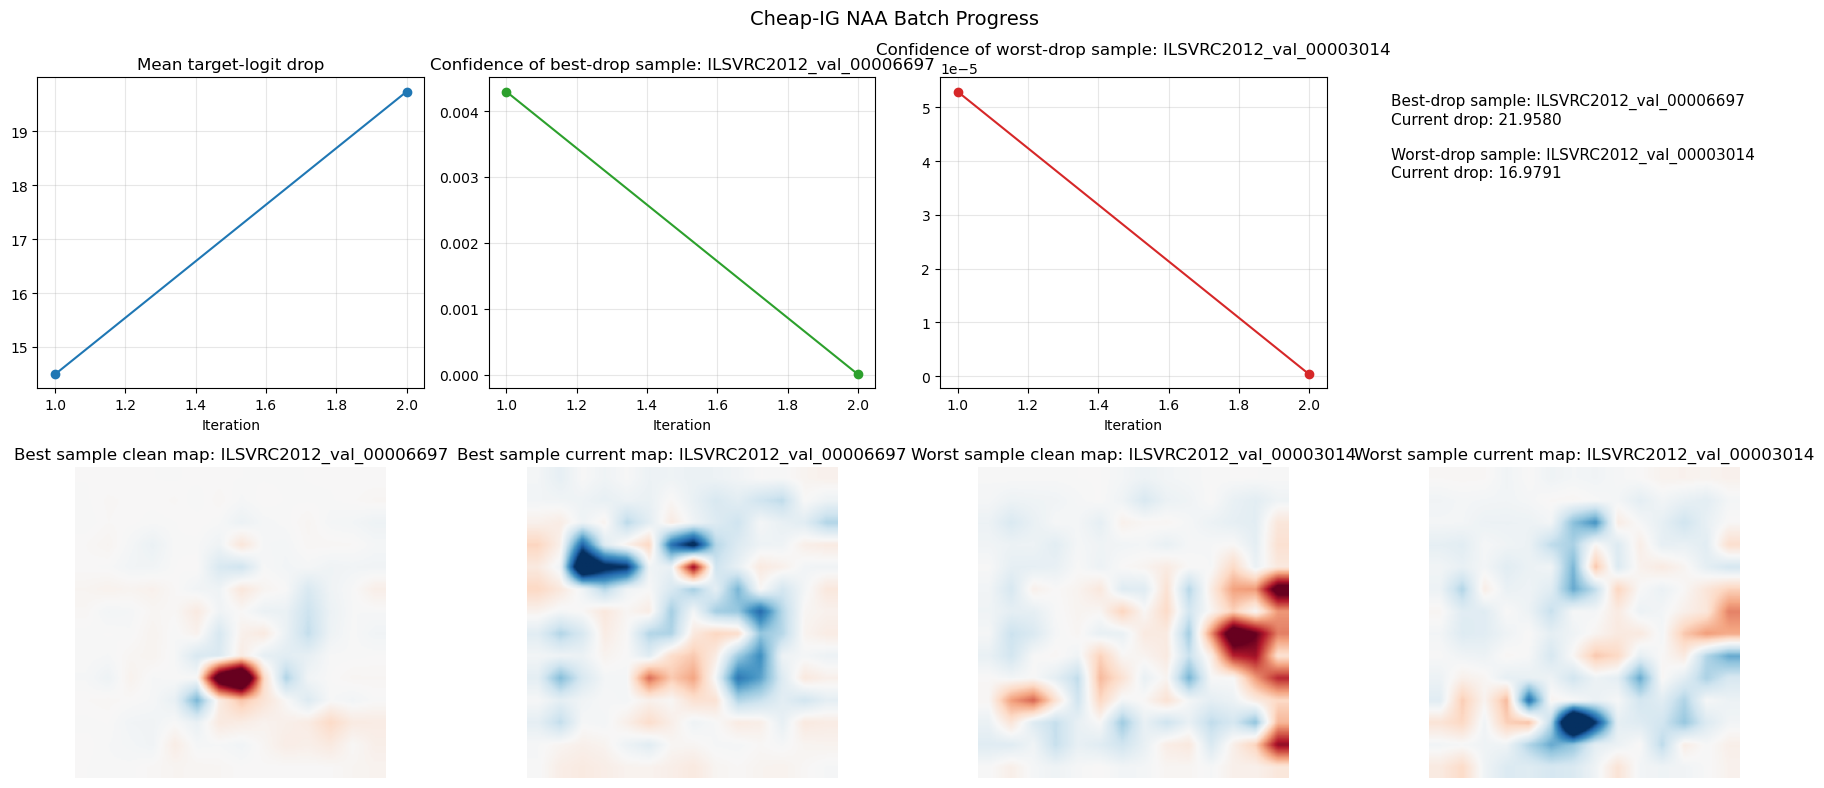

[step 02/10] loss=-1.98525 mean_drop=19.73539


KeyboardInterrupt: 

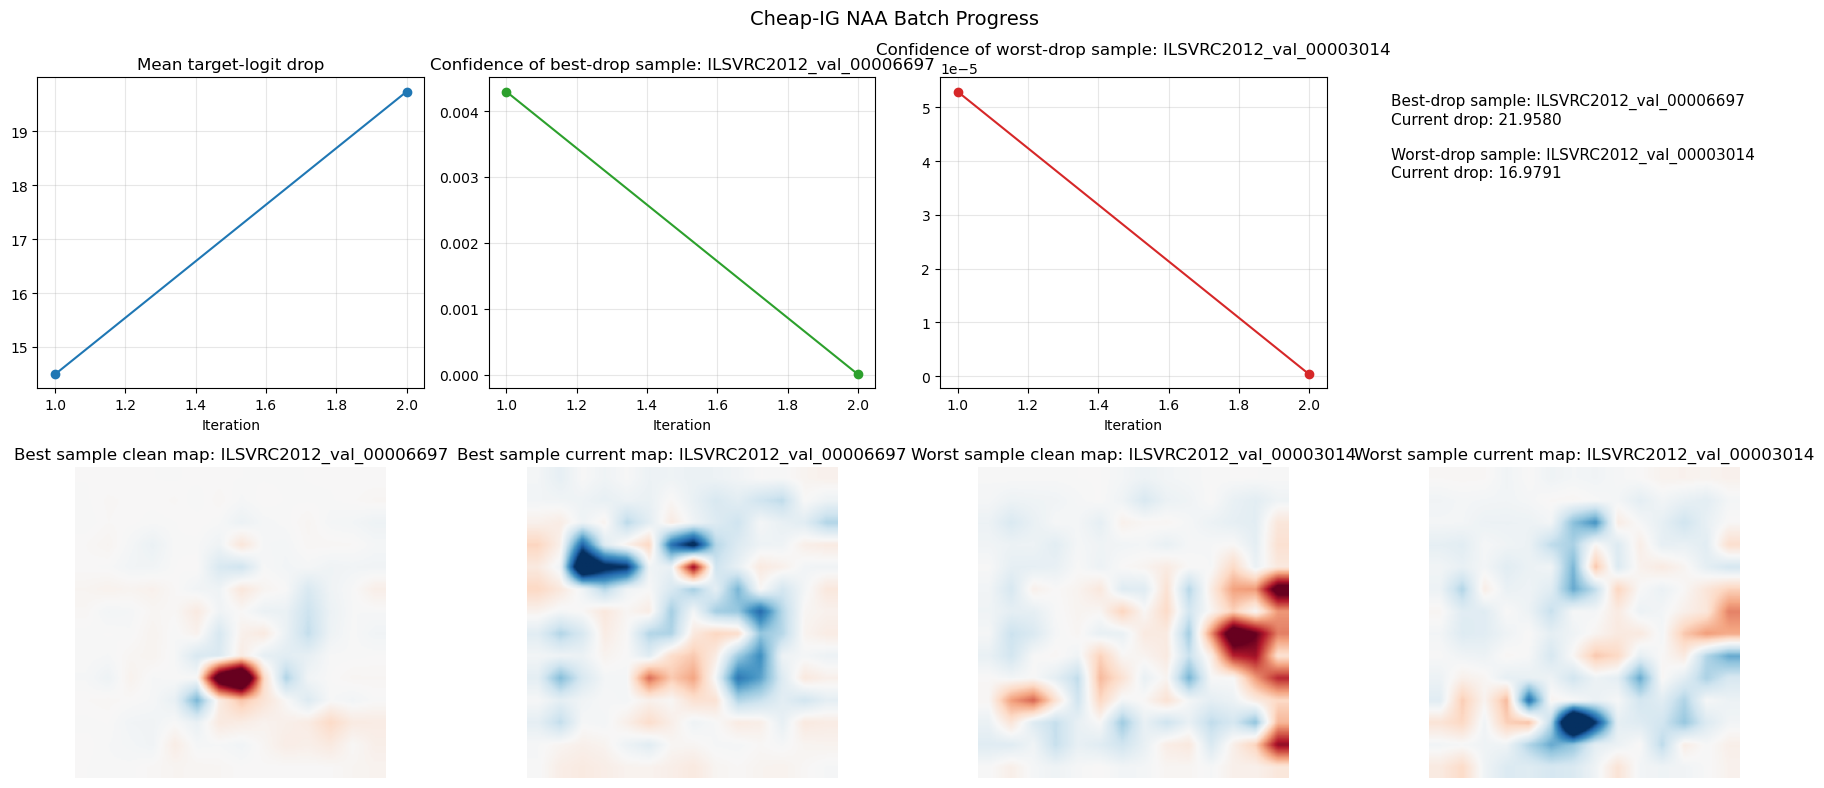

In [10]:
# Batch experiment.
batch_image_paths = image_paths[: min(4, len(image_paths))]

cheap_batch_config = AttackConfig(
    output_dir=ROOT / "outputs_compare_batch" / "cheap_ig",
    variant="base",
    batch_size=len(batch_image_paths),
    live_plots=True,
    verbose=True,
)
naa_batch_config = AttackConfig(
    output_dir=ROOT / "outputs_compare_batch" / "naa",
    variant="base",
    batch_size=len(batch_image_paths),
    live_plots=True,
    verbose=True,
)

cheap_batch_result = run_attack(batch_image_paths, cheap_batch_config)
naa_batch_result = run_naa_attack(batch_image_paths, naa_batch_config)
fig_curves = plot_attack_comparison(cheap_batch_result, naa_batch_result)
fig_maps = plot_importance_map_comparison(cheap_batch_result, naa_batch_result)
display(fig_curves)
display(fig_maps)

print(f"{cheap_batch_result.method_name}: total={cheap_batch_result.total_runtime_seconds:.2f}s, attribution={cheap_batch_result.attribution_runtime_seconds:.2f}s")
print(f"{naa_batch_result.method_name}: total={naa_batch_result.total_runtime_seconds:.2f}s, attribution={naa_batch_result.attribution_runtime_seconds:.2f}s")


In [8]:
# Optional PD-wrapped comparison with the same images.
#
# cheap_pd_config = AttackConfig(
#     output_dir=ROOT / "outputs_compare_pd" / "cheap_ig",
#     variant="pd",
#     live_plots=True,
#     verbose=True,
# )
# naa_pd_config = AttackConfig(
#     output_dir=ROOT / "outputs_compare_pd" / "naa",
#     variant="pd",
#     live_plots=True,
#     verbose=True,
# )
# cheap_pd_result = run_attack(single_image_paths, cheap_pd_config)
# naa_pd_result = run_naa_attack(single_image_paths, naa_pd_config)
# fig_curves = plot_attack_comparison(cheap_pd_result, naa_pd_result)
# fig_maps = plot_importance_map_comparison(cheap_pd_result, naa_pd_result)
# fig_curves
# fig_maps
